In [1]:
import anndata as ad
import pandas as pd
import numpy as np
from pathlib import Path
import os
import socket
from itertools import islice
from sklearn.decomposition import PCA
import scanpy as sc
import matplotlib.pyplot as plt

print(f"Running on node: {socket.gethostname()}")
print(os.getcwd())
print(os.path.expanduser("~"))

Running on node: hpclogin1
/work3/s252608/DL_project/notebooks
/zhome/f0/0/222976


In [2]:
def normalize(adata, target_sum=1e4):
    adata.layers["raw_counts"] = adata.X.copy()
    sc.pp.normalize_total(adata, target_sum=target_sum)
    sc.pp.log1p(adata)
    
    return adata

In [ ]:
def select_hvgs(adata, n_top=8000):
    if adata.isbacked:
        adata = adata.to_memory()
    sc.pp.highly_variable_genes(
        adata, 
        n_top_genes=n_top, 
        flavor='seurat_v3'
    )
    final_hvg_indices = adata.var.highly_variable
    adata_final = adata[:, final_hvg_indices].copy()
    
    print(f"Selected the top {adata_final.n_vars} HVGs.")
    return adata_final

In [4]:
source_path = Path("/work3/s252608/DL_project/data/raw")

In [5]:
adata = ad.read_h5ad(f'{source_path}/bulk_processed_genes.h5ad', backed = 'r')

In [50]:
adata_bulk_hvg = select_hvgs(adata, n_top=8000)
adata_bulk_hvg = normalize(adata_bulk_hvg)

Selected the top 8000 HVGs.


In [33]:
n_comps = 50
x_data = adata_bulk_hvg.X.toarray() if hasattr(adata_bulk_hvg.X, "toarray") else adata_bulk_hvg.X
pca = PCA(n_components=n_comps)
pca_coords = pca.fit_transform(x_data)

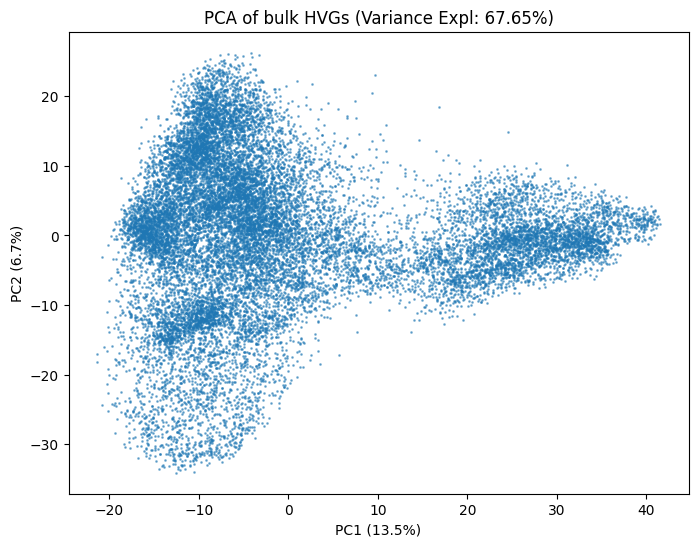

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(pca_coords[:, 0], pca_coords[:, 1], alpha=0.5, s=1)
plt.title(f"PCA of bulk HVGs (Variance Expl: {pca.explained_variance_ratio_.sum():.2%})")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.savefig('/zhome/bf/7/219671/projects/DL_project/results/bulk_pca_plot.png')

In [51]:
adata_bulk_hvg.obs

,geo_accession,series_id,characteristics_ch1,extract_protocol_ch1,source_name_ch1,title,contact_city,contact_country,contact_institute,instrument_model,...,pct_counts_mt,total_counts_ribo,pct_counts_ribo,total_counts_hb,pct_counts_hb,mt_outlier,n_counts,n_genes,leiden,avg_isoform_complexity
GSM1019741,GSM1019741,"GSE41586,GSE41588","cell line: HT29,cell type: colon cancer,treatm...","Each monolayer was washed with PBS, scraped an...",HT29 treated with 10 Î¼M of 5-Aza,"HT29 at 10 Î¼M of 5-Aza, biological rep1",Stony Brook,USA,Stony Brook University BME,Illumina HiSeq 2000,...,18.870185,240636,1.732672,926,0.006668,False,13888147,38534,0,4.930396
GSM1020212,GSM1020212,GSE41616,"cell type: corneal endothelial cells,age: 31y",RNA were extracted from those adult and fetal ...,corneal endothelial cells,adult CEC 33,Los Angeles,USA,UCLA,Illumina HiSeq 2000,...,15.738305,1845650,3.259948,2783,0.004916,False,56615931,36346,0,4.982407
GSM1041196,GSM1041196,"GSE42509,GSE45833","cell line: BJ cells,condition: pre-senescence;...",Total RNA was isolated using Trizol Reagent (I...,Immortalized primary fibroblasts,preS2.rna,Tel Aviv,Israel,Tel Aviv University,Illumina HiSeq 2000,...,5.669955,846995,4.443870,1953,0.010247,False,19059850,32669,0,5.396419
GSM1060226,GSM1060226,GSE43296,"cell line: MDA-MB-231,treatment: CXCL12 (0ng/m...",Polysome-associated RNA was extracted followin...,cells in culture,0+0_a,New York,USA,Memorial Sloan-Kettering Cancer Center,Illumina HiSeq 2000,...,0.055368,2003235,7.101789,4441,0.015744,False,28207470,28567,1,5.490397
GSM1060355,GSM1060355,GSE43306,"cell line: EGFP-10a+ MDA-MB-231,protocol: supp...",Polysome-associated RNA was extracted followin...,mammary tumor xenograft,M10,New York,USA,Memorial Sloan-Kettering Cancer Center,Illumina HiSeq 2000,...,0.588234,10216154,17.880799,7510,0.013144,False,57134775,32059,1,5.089920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM979657,GSM979657,GSE34448,"datatype: Cage,datatype description: CAGE 5' R...",http://genome.ucsc.edu/cgi-bin/hgTrackUi?db=hg...,MCF-7,RIKEN_Cage_MCF-7_cytosol_longPolyA,Stanford,USA,ENCODE DCC,Illumina HiSeq 2000,...,2.265183,1895689,15.479077,777,0.006345,False,12246783,21311,0,6.044158
GSM981248,GSM981248,"GSE26284,GSE30567","datatype: RnaSeq,datatype description: Sequenc...",http://genome.ucsc.edu/cgi-bin/hgTrackUi?db=hg...,IMR90,CSHL_RnaSeq_IMR90_nucleus_longPolyA (supersede...,Stanford,USA,ENCODE DCC,Illumina HiSeq 2000,...,0.692643,2356466,1.832919,15660,0.012181,False,128563550,43611,0,4.638446
GSM984613,GSM984613,GSE30567,"datatype: RnaSeq,datatype description: Sequenc...",http://genome.ucsc.edu/cgi-bin/hgTrackUi?db=hg...,HSaVEC,CSHL_RnaSeq_HSaVEC_cell_total (superseded by G...,Stanford,USA,ENCODE DCC,Illumina HiSeq 2000,...,17.314112,1467933,1.669890,6504,0.007399,False,87905964,39739,0,4.928422
GSM994762,GSM994762,"GSE40475,GSE40476","cell line: SUDHL6,treatment: iEZH",RNA-seq,Diffuse large B cell lymphoma,SUDHL6 iEZH D4 R2,Cambridge,USA,Constellation Pharmaceuticals,Illumina HiSeq 2000,...,5.222050,9676442,13.657157,2823,0.003984,False,70852533,36248,3,5.008836


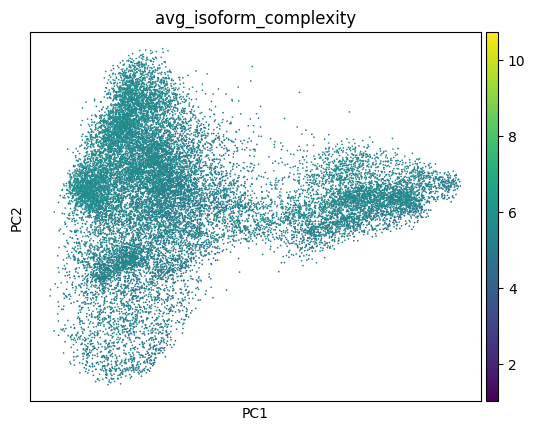

In [47]:
adata_bulk_hvg.obsm['X_pca'] = pca_coords
expressed_mask = (adata_bulk_hvg.X > 0).toarray() 
isoform_complexity = (expressed_mask @ adata_bulk_hvg.var['n_transcripts'].values) / expressed_mask.sum(axis=1)
adata_bulk_hvg.obs['avg_isoform_complexity'] = isoform_complexity

sc.pl.pca(adata_bulk_hvg, color='avg_isoform_complexity', components='1,2')

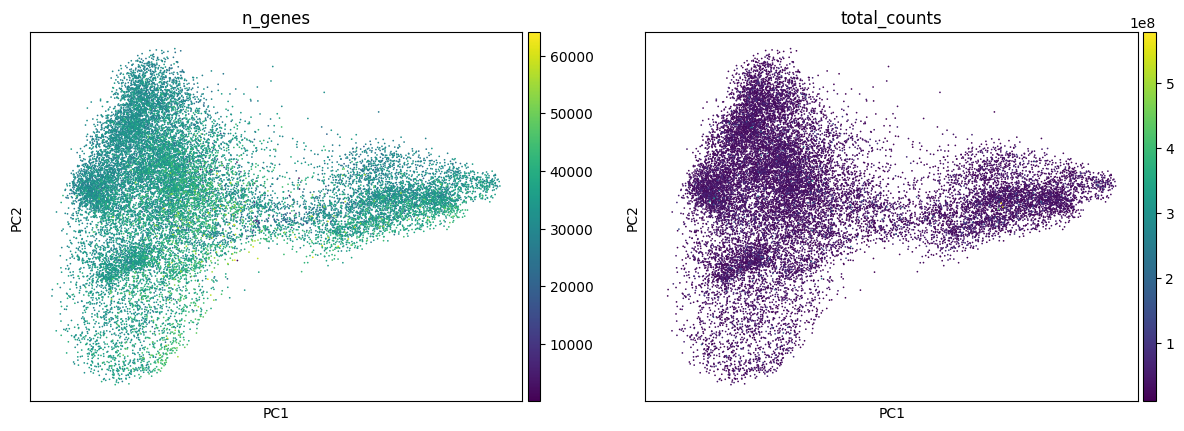

In [ ]:
sc.pl.pca(adata_bulk_hvg, color=['n_genes', 'total_counts'], components='1,2')

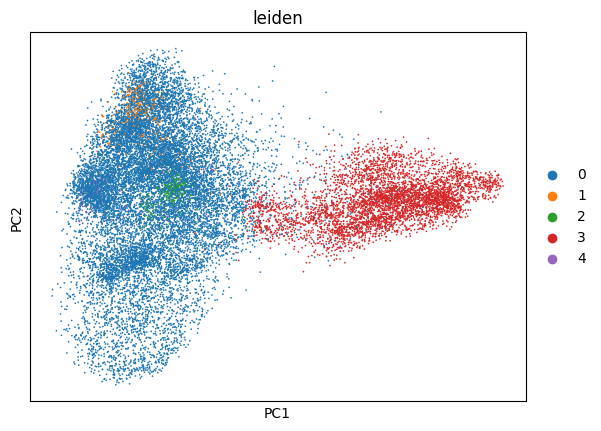

In [53]:
sc.pl.pca(adata_bulk_hvg, color='leiden', components='1,2')

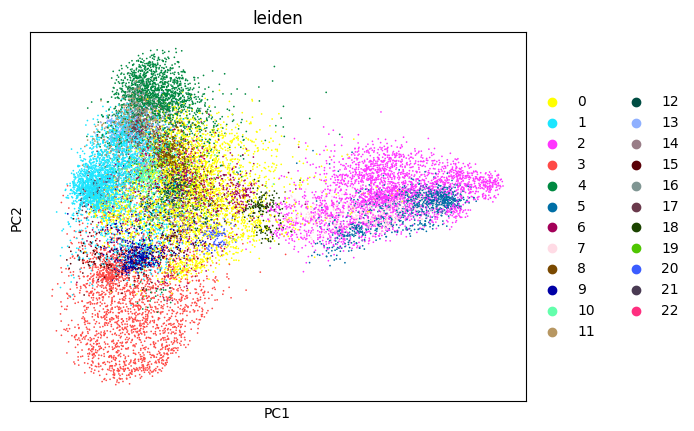

In [57]:
sc.pp.neighbors(adata_bulk_hvg, n_pcs=50, use_rep='X_pca')
sc.tl.leiden(adata_bulk_hvg, resolution=0.2)
sc.pl.pca(adata_bulk_hvg, color='leiden', components='1,2')

In [6]:
if adata.isbacked:
    adata = adata.to_memory()

genes_subset = pd.read_csv('/work3/s252608/DL_project/data/qc/bulk_processed_qc_relaxed_labels.csv')
genes_list = genes_subset[genes_subset['qc_pass_relaxed']==True]['gene_id']
print(len(genes_list))

2204


In [16]:
overlap_count = adata_bulk_hvg.var_names.isin(genes_list).sum()
print(overlap_count)

265


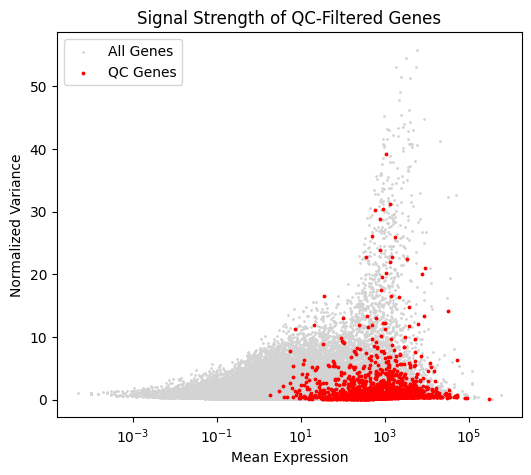

In [7]:
adata.var['is_qc_pass'] = adata.var_names.isin(genes_list)

sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=8000)

plt.figure(figsize=(6, 5))
plt.scatter(adata.var['means'], adata.var['variances_norm'], s=1, c='lightgrey', label='All Genes')
plt.scatter(adata.var.loc[genes_list, 'means'], 
            adata.var.loc[genes_list, 'variances_norm'], 
            s=3, c='red', label='QC Genes')
plt.xscale('log')
plt.xlabel('Mean Expression')
plt.ylabel('Normalized Variance')
plt.legend()
plt.title('Signal Strength of QC-Filtered Genes')
plt.show()

In [8]:
adata_sub = adata[:, genes_list].copy()
print(adata_sub)

AnnData object with n_obs × n_vars = 19882 × 2204
    obs: 'geo_accession', 'series_id', 'characteristics_ch1', 'extract_protocol_ch1', 'source_name_ch1', 'title', 'contact_city', 'contact_country', 'contact_institute', 'instrument_model', 'library_source', 'organism_ch1', 'platform_id', 'singlecellprobability', 'submission_date', 'taxid_ch1', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'mt_outlier', 'n_counts', 'n_genes', 'leiden'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'n_transcripts', 'is_single_isoform', 'is_qc_pass', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'gene_n_transcripts', 'gene_to_transcripts', 'instrument_model_colors', 'lei

/zhome/bf/7/219671/projects/DL_project/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_611377/2591973513.py:6: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_sub, resolution=0.2)


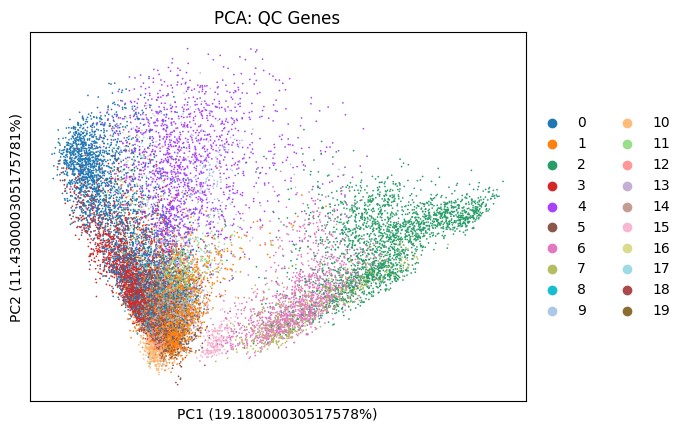

In [10]:
adata_sub = normalize(adata_sub)

sc.tl.pca(adata_sub, n_comps=128)

sc.pp.neighbors(adata_sub, n_pcs=128, use_rep='X_pca')
sc.tl.leiden(adata_sub, resolution=0.2)

sc.pl.pca(
    adata_sub, 
    color='leiden', 
    title="PCA: QC Genes",
    annotate_var_explained=True
)

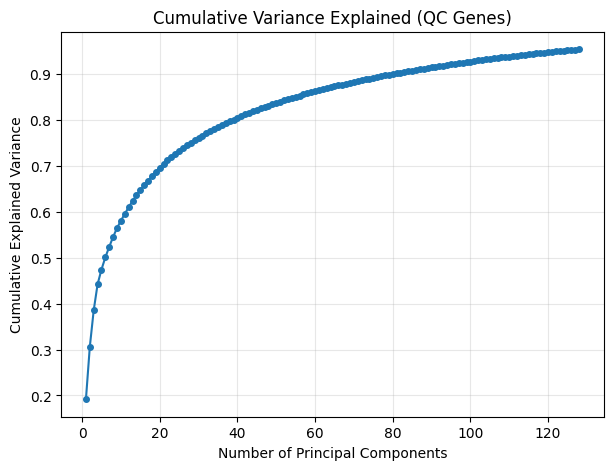

Total variance explained by 128 PCs: 95.39%


In [12]:
var_ratios = adata_sub.uns['pca']['variance_ratio']
cum_var = np.cumsum(var_ratios)

plt.figure(figsize=(7, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o', linestyle='-', markersize=4)

plt.title("Cumulative Variance Explained (QC Genes)")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Total variance explained by {len(cum_var)} PCs: {cum_var[-1]*100:.2f}%")

## VAE Representation Analysis

In [3]:
import numpy as np

vae_embedding = np.load(
    "/work3/s252608/DL_project/data/representations/bulk_vae_dim128.npy"
)

adata.obsm["X_vae"] = vae_embedding

NameError: name 'adata' is not defined

In [ ]:
def run_umap(adata, rep_name, resolution=0.2):

    sc.pp.neighbors(
        adata,
        use_rep=rep_name
    )

    sc.tl.leiden(
        adata,
        resolution=resolution
    )

    sc.tl.umap(adata)

    sc.pl.umap(
        adata,
        color="leiden",
        title=f"UMAP: {rep_name}"
    )